# Sentiment Analysis: SVM Pipeline with SMOTE and Hyperparameter Tuning

## **Research Methodology: SVM Sentiment Classification Pipeline**
This notebook demonstrates a rigorous approach to sentiment analysis on imbalanced text data, comparing a cost-sensitive baseline against an optimized model using SMOTE (Synthetic Minority Over-sampling Technique) and GridSearchCV.

# **Libraries**

In [1]:
!pip install scikit-learn pandas numpy openpyxl matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# **Train**

In [3]:
label2id = {"negatif": 0, "netral": 1, "positif": 2}
id2label = {0: "negatif", 1: "netral", 2: "positif"}
RANDOM_STATE = 42

In [4]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the text data after splitting in the next steps
print("TF-IDF Vectorizer initialized.")

TF-IDF Vectorizer initialized.


In [5]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Updated path to your specific preprocessed dataset
file_path = '/content/drive/MyDrive/Thesis/final_normalized_preprocessed.xlsx'

# Load the dataset
df = pd.read_excel(file_path)

# 1. Basic Cleaning: Drop rows where clean_text or sentiment is missing
df = df.dropna(subset=['clean_text', 'sentiment'])

# 2. Standardize labels (remove whitespace and lowercase) to ensure mapping works
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

# 3. Map labels to IDs
df['sentiment'] = df['sentiment'].map(label2id)

# 4. Final check: Drop any rows where mapping failed (if any unexpected labels existed)
df = df.dropna(subset=['sentiment'])
df['sentiment'] = df['sentiment'].astype(int)

print(f"Dataset loaded and cleaned. Final count: {len(df)} samples.")
display(df.head())
print("Label distribution:")
print(df['sentiment'].value_counts())

Mounted at /content/drive
Dataset loaded and cleaned. Final count: 6028 samples.


,Unnamed: 0,reviewId,content,normalized,clean_text,sentiment
0,0,6a7dbd15-2507-4f2c-bd2c-d36bbc89c640,masa Bank BUMN terbesar rating nya 4.1..tadiny...,mengapa peringkat bank bumn terbesar demikian ...,peringkat bank bumn terbesar tidak mengeluhkan...,0
1,1,c7f1469f-42f5-4dad-86eb-13aca28e5cf7,kenapa tidak bisa masuk ke aplikasi livin kami...,mengapa tidak bisa masuk ke aplikasi livin kam...,tidak masuk aplikasi livin peningkatan layanan...,1
2,2,3bde987d-6726-4ed8-8cc7-de39a3331f68,"heran aku, kejadian bukan 1 kali jadi di ATM s...",saya heran kejadian ini bukan pertama kalinya ...,heran kejadian bukan kalinya atm bri saldo pul...,0
3,3,91616e30-ada7-4242-8872-ab3e310881f2,Apk nya bagus cmn kebykn nyangkut di e-toll ud...,aplikasinya bagus namun sering macet di e toll...,aplikasinya bagus macet e toll pengisian ulang...,0
4,4,beffc9f7-fa71-4ab9-9fe8-17c66bab72b0,knp kalo mau transfer harus upgrade ke gopay p...,mengapa jika ingin mentransfer harus upgrade k...,mentransfer upgrade gopay plus,1


Label distribution:
sentiment
0    4472
2     906
1     650
Name: count, dtype: int64


In [6]:
X = df['clean_text']
y = df['sentiment']
# step 1 — 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
# step 2 — 50% of temp = 10% total test, rest = 10% val
X_val, X_test, y_val, y_test = train_test_split(
X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print(f"Train : {len(X_train)} samples")
print(f"Val : {len(X_val)} samples")
print(f"Test : {len(X_test)} samples")


Train : 4822 samples
Val : 603 samples
Test : 603 samples


In [7]:
# Transform text to TF-IDF features
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF transformation complete.")
print(f"Train shape: {X_train_tfidf.shape}")

TF-IDF transformation complete.
Train shape: (4822, 3575)


## 1. Baseline Model (Weighted SVM)
We start by training a baseline SVM using `class_weight='balanced'`. This helps the model acknowledge underrepresented classes without synthetic oversampling.

--- Baseline Model (Validation) ---
              precision    recall  f1-score   support

     negatif       0.92      0.76      0.83       447
      netral       0.22      0.46      0.30        65
     positif       0.83      0.88      0.86        91

    accuracy                           0.75       603
   macro avg       0.66      0.70      0.66       603
weighted avg       0.83      0.75      0.78       603

Accuracy: 0.7479 | F1-Score: 0.7793 | ROC-AUC: 0.8994



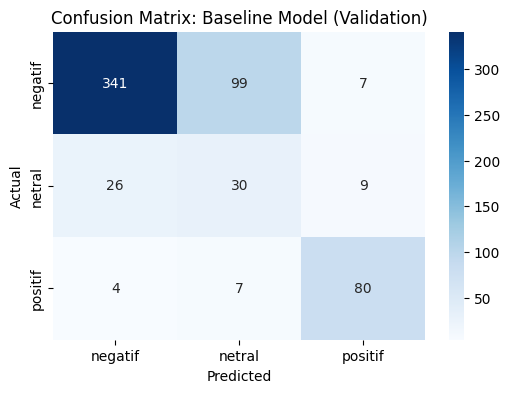

In [8]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def run_evaluation(model, X, y, title):
    """Utility function to display metrics and confusion matrix."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    print(f"--- {title} ---")
    print(classification_report(y, y_pred, target_names=list(label2id.keys())))

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='weighted')
    auc = roc_auc_score(y, y_prob, multi_class='ovr', average='weighted')

    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | ROC-AUC: {auc:.4f}\n")

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label2id.keys(), yticklabels=label2id.keys())
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return {"accuracy": acc, "f1": f1, "roc_auc": auc}

# Train Baseline
baseline_svm = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
baseline_svm.fit(X_train_tfidf, y_train)

# Evaluate Baseline on Validation Set
val_metrics_base = run_evaluation(baseline_svm, X_val_tfidf, y_val, "Baseline Model (Validation)")

## 2. Model Optimization: SMOTE + GridSearchCV
To further improve performance, we use **SMOTE** to balance the training set and **GridSearchCV** to find the optimal SVM kernel and parameters.

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
--- Optimized Model (SMOTE + Weighted) ---
              precision    recall  f1-score   support

     negatif       0.87      0.96      0.91       447
      netral       0.26      0.14      0.18        65
     positif       0.92      0.77      0.84        91

    accuracy                           0.84       603
   macro avg       0.69      0.62      0.64       603
weighted avg       0.81      0.84      0.82       603

Accuracy: 0.8425 | F1-Score: 0.8227 | ROC-AUC: 0.8753



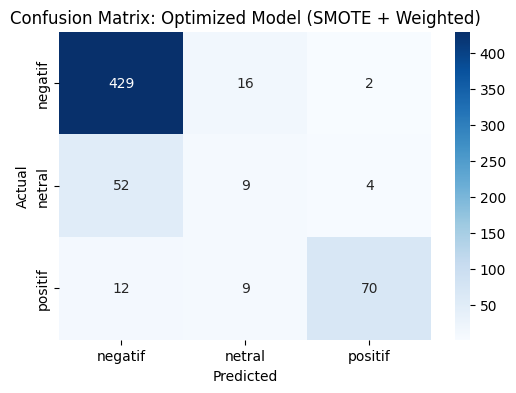

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# 1. SMOTE: Synthetic oversampling to balance class sizes
smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X_train_tfidf, y_train)

# 2. Hyperparameter Grid
param_grid = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

# 3. GridSearchCV: Using SMOTE-resampled data AND class_weight='balanced' for training
# This dual approach handles imbalance via both resampling and cost-sensitive learning
grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)
grid.fit(X_res, y_res)

best_svm = grid.best_estimator_
print(f"Best Parameters: {grid.best_params_}")

# Evaluate Optimized Model on Validation Set
val_metrics_opt = run_evaluation(best_svm, X_val_tfidf, y_val, "Optimized Model (SMOTE + Weighted)")

## 3. Final Evaluation (Test Set)
Now we perform the final assessment using the **Optimized Model** on the unseen test data. This represents the real-world performance.

--- Optimized Model (Final Test) ---
              precision    recall  f1-score   support

     negatif       0.90      0.96      0.93       448
      netral       0.46      0.28      0.35        65
     positif       0.88      0.86      0.87        90

    accuracy                           0.87       603
   macro avg       0.75      0.70      0.71       603
weighted avg       0.85      0.87      0.85       603

Accuracy: 0.8673 | F1-Score: 0.8547 | ROC-AUC: 0.9267



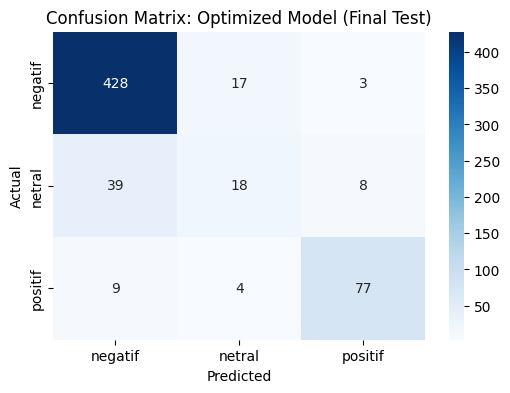

In [10]:
# Final evaluation on the Test Set
test_metrics_final = run_evaluation(best_svm, X_test_tfidf, y_test, "Optimized Model (Final Test)")

### **4. Result Archiving (For Research Documentation)**
Exporting the final predictions to Google Drive for later qualitative analysis and inclusion in the paper's appendix.

In [11]:
import os

# Generate final predictions using the best model
y_pred_final = best_svm.predict(X_test_tfidf)

# Create a consolidated results dataframe
results_df = pd.DataFrame({
    'Clean_Text': X_test.values,
    'Actual_Sentiment': [id2label[i] for i in y_test],
    'Predicted_Sentiment': [id2label[i] for i in y_pred_final]
})

# Save to Drive
output_path = '/content/drive/MyDrive/Thesis/results/final_svm_research_results.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
results_df.to_csv(output_path, index=False)

print(f"Final research results saved to: {output_path}")
display(results_df.head(10))

Final research results saved to: /content/drive/MyDrive/Thesis/results/final_svm_research_results.csv


,Clean_Text,Actual_Sentiment,Predicted_Sentiment
0,ovo mentransfer uang rekening bank pagi sore t...,negatif,negatif
1,mencoba menabung mengisi saldo biaya transfern...,negatif,negatif
2,ovo tidak jam mengisi ulang saldo tidak masuk ...,negatif,negatif
3,pengisian saldo tidak masuk ajukan pengembalia...,negatif,negatif
4,membantu mudah sayang batas pengisian saldo ju...,netral,positif
5,top up ovo kemarin malam tidak masuk tidak ban...,negatif,negatif
6,gopay menyenangkan bebas transfer tanpa hambat...,positif,positif
7,mengisi saldo akunnya diblokir membukanya meng...,negatif,negatif
8,kali transfer terhambat diproses menunggu ming...,negatif,negatif
9,proses masuknya kasir,negatif,negatif


### **Class Distribution Analysis**

/tmp/ipykernel_512/2252079868.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=label_counts.values, palette='viridis')


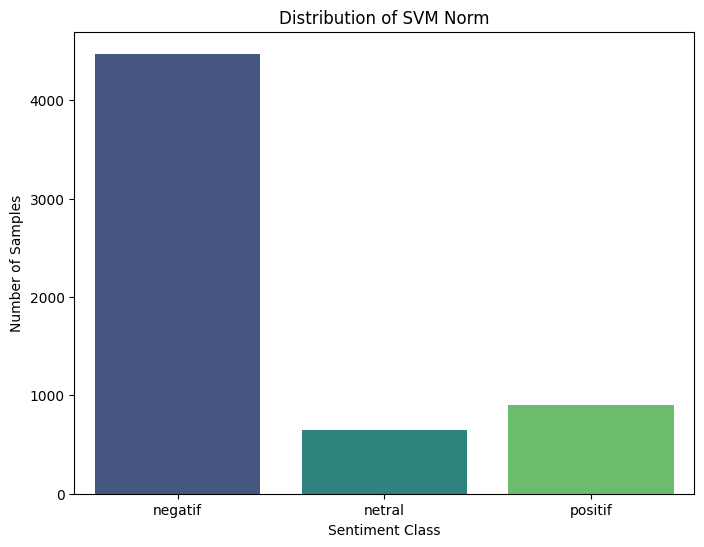

Label Distribution:
sentiment
negatif    4472
netral      650
positif     906
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the sentiment column
label_counts = df['sentiment'].value_counts().sort_index()

# Map numerical labels back to descriptive names for plotting
labels = [id2label[i] for i in label_counts.index]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=label_counts.values, palette='viridis')
plt.title('Distribution of SVM Norm')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.show()

print("Label Distribution:")
print(label_counts.rename(index=id2label))

In [13]:
# import numpy as np
# from sklearn.preprocessing import label_binarize
# from sklearn.metrics import roc_curve, auc
# import os
# import matplotlib.pyplot as plt

# # --- Configuration for saving ROC data ---
# ROC_MODEL_NAME = "SVM-Lexnorm"
# ROC_SAVE_DIR = "/content/drive/MyDrive/Thesis/results/roc_data"
# NUM_CLASSES = 3

# id2label = {0: "negatif", 1: "netral", 2: "positif"}
# label2id = {"negatif": 0, "netral": 1, "positif": 2}

# def save_macro_roc_data(y_true, y_score, model_name, num_classes, save_dir="roc_data"):
#     """
#     Calculates macro-averaged ROC curve data and saves it to a .npz file.

#     Args:
#         y_true (array-like): True integer class labels.
#         y_score (array-like): Predicted probabilities (n_samples, n_classes).
#         model_name (str): Name of the model (used for filename).
#         num_classes (int): Number of classes.
#         save_dir (str): Directory to save the .npz files.

#     Returns:
#         tuple: (all_fpr, mean_tpr, macro_auc)
#     """
#     os.makedirs(save_dir, exist_ok=True)

#     y_true = np.asarray(y_true)
#     y_score = np.asarray(y_score)

#     # Binarize true labels for one-vs-rest
#     y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
#     if num_classes == 2:
#         # label_binarize collapses to 1 column for 2 classes; expand back to 2
#         y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

#     # Compute ROC curve + AUC for each class
#     fpr_dict, tpr_dict = {}, {}
#     for i in range(num_classes):
#         fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])

#     # --- Macro-average: interpolate each class curve onto a common FPR grid, then average TPR ---
#     all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(num_classes)]))
#     mean_tpr = np.zeros_like(all_fpr)
#     for i in range(num_classes):
#         mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
#     mean_tpr /= num_classes

#     macro_auc = auc(all_fpr, mean_tpr)

#     out_path = os.path.join(save_dir, f"SVM_Norm.npz")
#     np.savez(out_path, fpr=all_fpr, tpr=mean_tpr, auc=macro_auc)
#     print(f"Saved {model_name}: macro-average AUC = {macro_auc:.4f} to {out_path}")

#     return all_fpr, mean_tpr, macro_auc

# # --- For SVM ---
# # Get predictions and true labels from the optimized SVM model
# y_true = y_test
# y_score = best_svm.predict_proba(X_test_tfidf) # Using best_svm and X_test_tfidf

# # Save ROC data for SVM
# svm_fpr, svm_tpr, svm_auc = save_macro_roc_data(y_true, y_score, model_name="SVM-Lexnorm", num_classes=NUM_CLASSES, save_dir=ROC_SAVE_DIR)

# # --- Plotting the ROC curve for SVM ---
# plt.figure(figsize=(8, 6))
# plt.plot(svm_fpr, svm_tpr, color='darkorange', lw=2, label=f'SVM-Lexnorm (AUC = {svm_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve - SVM-Lexnorm')
# plt.legend(loc="lower right")
# plt.grid(True)
# plt.show()


### **5. Precision-Recall Curve Analysis**
Precision-Recall curves are often more informative than ROC curves for imbalanced datasets as they focus on the performance of the minority classes.

Saved PR Data for SVM-Lexnorm: macro-average PR-AUC = 0.7465 to /content/drive/MyDrive/Thesis/results/pr_data/SVM_Norm_PR.npz


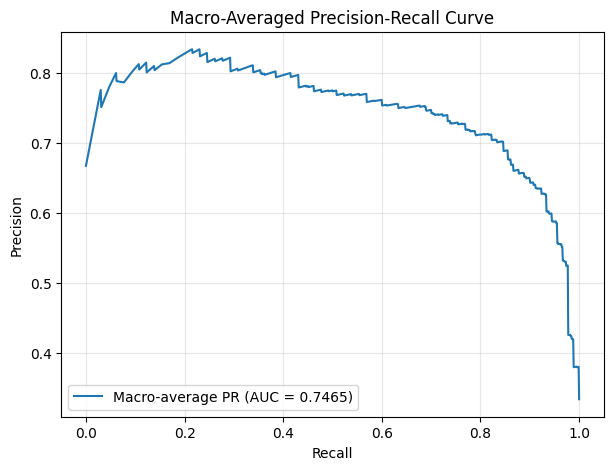

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import os
import matplotlib.pyplot as plt

def save_macro_pr_data(y_true, y_score, model_name, num_classes, save_dir="/content/drive/MyDrive/Thesis/results/pr_data"):
    """
    Calculates macro-averaged Precision-Recall data and saves to .npz.
    """
    os.makedirs(save_dir, exist_ok=True)

    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    if num_classes == 2:
        y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

    # Precision and recall for each class
    precision_dict = {}
    recall_dict = {}

    # Use a common grid for interpolation (Recall from 0 to 1)
    mean_recall = np.linspace(0, 1, 1000)
    mean_precision = np.zeros_like(mean_recall)

    for i in range(num_classes):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        # Interpolate precision to the common recall grid
        mean_precision += np.interp(mean_recall, recall_dict[i][::-1], precision_dict[i][::-1])

    mean_precision /= num_classes
    macro_pr_auc = auc(mean_recall, mean_precision)

    out_path = os.path.join(save_dir, f"SVM_Norm_PR.npz")
    np.savez(out_path, recall=mean_recall, precision=mean_precision, auc=macro_pr_auc)

    print(f"Saved PR Data for {model_name}: macro-average PR-AUC = {macro_pr_auc:.4f} to {out_path}")

    return mean_recall, mean_precision, macro_pr_auc

# --- Define required variables to fix NameError ---
# Configuration used from previous steps
ROC_MODEL_NAME = "SVM-Lexnorm"
NUM_CLASSES = 3
y_true = y_test
y_score = best_svm.predict_proba(X_test_tfidf)

# --- Calculate and Save PR Data ---
recall_grid, precision_grid, pr_auc = save_macro_pr_data(
    y_true=y_true,
    y_score=y_score,
    model_name=ROC_MODEL_NAME,
    num_classes=NUM_CLASSES,
    save_dir="/content/drive/MyDrive/Thesis/results/pr_data"
)

# Quick Plot visualization
plt.figure(figsize=(7, 5))
plt.plot(recall_grid, precision_grid, label=f'Macro-average PR (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()